# Best Practices und Performance


## Vertiefung


### Übersicht


1. Ziele bei der Programmierung von numerischen Algorithmen
2. Best Practices
3. Dokumentation
4. Performance
5. Profiling mit `cProfile`


In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Ziele bei der Programmierung von numerischen Algorithmen


- **Korrektheit**
  - Numerische Algorithmen müssen korrekt implementiert sein, d.h. sie müssen die mathematischen Konzepte und Theorien, auf denen sie basieren, genau widerspiegeln. 
- **Genauigkeit & Stabilität**
  - Numerische Algorithmen müssen in der Lage sein, Ergebnisse zu liefern, die innerhalb einer geforderten Toleranz genau sind. Dazu gehört auch, dass der Code numerische Instabilitäten vermeidet und robust gegenüber Störungen und Rundungsfehlern ist.
- **Effizienz**
  - Numerische Verfahren arbeiten oft mit grossen Datenmengen und müssen daher effizient sein, um innerhalb eines angemessenen Zeitrahmens ausgeführt werden zu können. Dazu gehört auch, dass der Code optimiert wird, um die bestmögliche Leistung aus der zugrundeliegenden Hardware herauszuholen.
- **Modularität**
  - Die Methoden bestehen oft aus mehreren Schritten oder Teilproblemen, die modular und wiederverwendbar sein sollten. Eine gute Modularität erleichtert auch das Testen und Debuggen des Codes.
- **Verständlichkeit**
  - Numerische Algorithmen können komplex sein. Also ist es wichtig, dass der Code so geschrieben ist, dass er leicht verständlich ist. Dazu gehört auch, dass der Code gut dokumentiert und strukturiert ist.


### 2. Best Practices


#### 2.1 Ziel Korrektheit

- Exakte Beschreibung der mathematischen Konzepte
- Exakte Implementierung der Algorithmen
- Fehlerhafte und inkonsistente Inputs abfangen und rückmelden
- Implementation anhand mehrerer Beispiele validieren (z.B. Vergleich mit anderen Methoden oder analytischen Lösungen)
- "Edge-Cases" auch in den Tests abdecken (z.B. Division durch Null, etc.)

#### 2.2 Ziel Genauigkeit & Stabilität

- Bestehende Lösungen (Packages) verwenden (aber nur vertrauenswürdige und gut gewartete Quellen)
- Numerische Instabilitäten vermeiden: 64-bit Fliesskommazahlen verwenden, Subtraktion von ähnlich grossen Zahlen (Auslöschung) und Division durch sehr kleine Zahlen vermeiden, etc.
- Toleranzen als Parameter bereitstellen und einhalten (z.B. bei der Konvergenz von Iterationsverfahren)
- Tests mit verschiedenen Toleranzen durchführen, sinnvolle Defaults angeben und ggf. Konvergenzgeschwindigkeit in der Dokumentation kommunizieren


#### 2.3 Ziel Effizienz

- Vermeiden von IO-Operationen (Console, Disk, Netzwerk, etc.)
- Vektorisierung (z.B. mit Slicing und [`np.vectorize`](https://numpy.org/doc/stable/reference/generated/numpy.vectorize.html))
- Parallelisierung (z.B. mit [`multiprocessing`](https://docs.python.org/3/library/multiprocessing.html))
- C-Code Kompilierung (z.B. mit [Numba](https://numba.pydata.org/) oder [Cython](https://cython.org/))
- Manchmal durch Mutationen (z.B. in-place Operationen auf Arrays)


#### 2.4 Ziel Modularität

- Funktionen und Methoden schreiben, die nur eine Aufgabe erfüllen.
- Gleichartige Funktionalität in ein Modul oder wenn nötig in eine Klasse packen.
- Klare Schnittstellen für Funktionen, Module und Klassen definieren, um Abhängigkeiten zu minimieren und transparent zu machen.
- Schnittstellen sollen sich an Standards orientieren (z.B. [NumPy](https://numpy.org/), [SciPy](https://www.scipy.org/), [Pandas](https://pandas.pydata.org/), etc.)


#### 2.5 Ziel Verständlichkeit

- Klare, konsistente und aussagekräftige Namen für Funktionen, Module, Klassen und Variablen verwenden.
- Funktionen, Module und Klasse mit aussagekräftiger Dokumentationen versehen, z.B. auch Referenzen zu implementierten Methode angeben.
- Tests schreiben, um die Funktionalität zu testen und um die Verständlichkeit zu erhöhen, indem sie gleich Beispielcode liefern.
- Automatische Code-Formatierung verwenden, um den Code zu standardisieren (z.B. [Black](https://pypi.org/project/black/), [autopep8](https://pypi.org/project/autopep8/)), siehe [Formatting Python in VS Code](https://code.visualstudio.com/docs/python/formatting).


### 3. Dokumentation


- Funktionen in einem Modul zusammenstellen
- Jede Funktion mit einem Docstring versehen
  - Was macht die Funktion?
  - Welche Annahmen werden gemacht?
  - Welche Parameter werden erwartet?
  - Welche Rückgabewerte werden erzeugt?
  - Beispiel


In der Datei `ngds.py` ist ein Modul definiert, das selbstgeschriebene Funktionen für numerische Berechnungen enthält. Das Modul kann hier importiert werden. Die Docstrings der Funktionen werden angezeigt, wenn man mit der Maus über dem Funktionsnamen ist, oder können mit `help()` aufgerufen werden.


In [2]:
import ngds

# Modul neu laden, wenn man Änderungen gemacht hat. Ohne Reload wird die alte Version verwendet.
from importlib import reload

reload(ngds)

# Docstring anzeigen
help(ngds.interpolate_linear)

Help on function interpolate_linear in module ngds:

interpolate_linear(x_data, y_data, x)
    Perform linear interpolation to estimate the value of a function at a given point.
    Parameters:
        x_data (array-like): A sequence of x-coordinates (must be sorted in ascending order).
        y_data (array-like): A sequence of y-coordinates corresponding to x_data.
        x (array-like): The x-coordinates at which to interpolate.
    Returns:
        float: The interpolated y-coordinate corresponding to the input x.
    Raises:
        AssertionError: If any of the following conditions are not met:
            - x_data and y_data are array-like structures.
            - x_data and y_data have the same length.
            - x_data and y_data contain at least two points.
            - x_data is sorted in ascending order.

    Notes:
        - This function assumes that x_data is sorted in ascending order.
        - The interpolation is performed using the formula:
          y = y_data

Und natürlich können die Funktionen auch direkt verwendet werden.


In [3]:
ngds.find_root_bisection(np.sin, -1.2, 1, 1e-6, 1e-6, 100)

array([[ 0.00000000e+00, -1.00000000e-01, -9.98334166e-02,
         1.10000000e+00,  9.98334166e-02],
       [ 1.00000000e+00,  4.50000000e-01,  4.34965534e-01,
         5.50000000e-01,  4.34965534e-01],
       [ 2.00000000e+00,  1.75000000e-01,  1.74108138e-01,
         2.75000000e-01,  1.74108138e-01],
       [ 3.00000000e+00,  3.75000000e-02,  3.74912116e-02,
         1.37500000e-01,  3.74912116e-02],
       [ 4.00000000e+00, -3.12500000e-02, -3.12449140e-02,
         6.87500000e-02,  3.12449140e-02],
       [ 5.00000000e+00,  3.12500000e-03,  3.12499491e-03,
         3.43750000e-02,  3.12499491e-03],
       [ 6.00000000e+00, -1.40625000e-02, -1.40620365e-02,
         1.71875000e-02,  1.40620365e-02],
       [ 7.00000000e+00, -5.46875000e-03, -5.46872274e-03,
         8.59375000e-03,  5.46872274e-03],
       [ 8.00000000e+00, -1.17187500e-03, -1.17187473e-03,
         4.29687500e-03,  1.17187473e-03],
       [ 9.00000000e+00,  9.76562500e-04,  9.76562345e-04,
         2.14843750e-03

### 4. Performance


> "Premature optimization is the root of all evil." (Donald Knuth)


#### 4.1 Einfache Zeitmessung mit [`timeit`](https://docs.python.org/3/library/timeit.html)


Für ein erstes Beispiel für die Zeitmessung mit [`timeit`](https://docs.python.org/3/library/timeit.html) wandeln wir ein NumPy Array mit Integers in Strings um und vergleichen verschiedene Lösungen 

In [4]:
numbers = np.arange(1_000)

In [5]:
print("Numpy astype")
%timeit numbers.astype(str)

print("List comprehension")
%timeit np.array([str(n) for n in numbers])

print("Generator expression")
%timeit np.array(list(str(n) for n in numbers))

print("Map")
%timeit np.array(list(map(str, numbers)))

Numpy astype
65.7 μs ± 1.25 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
List comprehension
98.5 μs ± 1.83 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Generator expression
105 μs ± 1.15 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Map
99 μs ± 589 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In NumPy bleiben ist also etwa doppelt so schnell wie eine Comprehension oder Map. Die Generator Expression ist immer ein Bisschen weniger effizient als die Comprehension. Meist ist Map auch minimal langsamer als die Comprehension. 


Als nächstes benutzen wir die Funktion [`str.join`](https://docs.python.org/3/library/stdtypes.html#str.join), die eine Sequenz von Strings mit einem Trennzeichen zu einem einzigen String zusammenfügt.

In [6]:
print("Numpy astype")
%timeit "-".join(numbers.astype(str))

print("List comprehension")
%timeit "-".join([str(n) for n in numbers])

print("Generator expression")
%timeit "-".join(str(n) for n in numbers)

print("Map")
%timeit "-".join(map(str, numbers))

Numpy astype
169 μs ± 1.02 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
List comprehension
58.1 μs ± 234 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Generator expression
63.9 μs ± 435 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Map
58.5 μs ± 469 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Interessanterweise ist hier Map am schnellsten, gefolgt von der Comprehension und dann der Generator Expression. Die Lösung mit NumPy ist wesentlich langsamer - weshalb ist nicht ganz klar.

Klar ist, dass es sich lohnt, verschiedene Lösungen zu vergleichen!

Zum Vergleich noch eine eigene Implementation, ohne die Funktion [`str.join`](https://docs.python.org/3/library/stdtypes.html#str.join) zu benutzen.


In [7]:
def join_numbers_by_hyphen(numbers):
    if len(numbers) == 0:
        return ""
    else:
        res = str(numbers[0])
        if len(numbers) > 1:
            for n in numbers[1:]:
                res += f"-{n}"
        return res

In [8]:
%timeit join_numbers_by_hyphen(numbers)

125 μs ± 5.68 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Gar nicht so übel, aber doch nicht besser.


Die folgenden Beispiele zeigen, dass es sich lohnt, NumPy Funktionen zu verwenden und nicht die generischen Python Funktionen.


In [9]:
n = 1_000_000
rng = np.random.default_rng(12345)
numbers = rng.random(n)


%timeit sum(numbers)
%timeit np.sum(numbers)

31.2 ms ± 258 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
116 μs ± 252 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [10]:
%timeit np.sum(numbers) / len(numbers)
%timeit np.mean(numbers)

116 μs ± 130 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
118 μs ± 1.35 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [11]:
# Mittelwert pro Block
block_size = 1_000
%timeit np.array([np.mean(numbers[pos : pos + block_size]) for pos in range(0, n, block_size)])
%timeit numbers.reshape(-1, block_size).mean(axis=1)

1.45 ms ± 17.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
124 μs ± 1.26 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


Hier zeigt sich, dass eine vektorisierte Lösung der Problemstellung mithilfe von Array-Denkweise gefunden werden kann und dann oft viel schneller als die Lösung mit Schleifen ist. GitHub Copilot kann hierbei helfen, die richtige Formulierung zu finden. Immer testen!


#### 4.2 Profiling mit [`cProfile`](https://docs.python.org/3/library/profile.html)


Video: ["Using "cProfile" to analyze Python code performance" - IDG TECHtalk](https://www.youtube.com/watch?v=dmnA3axZ3FY)

Als Beispiel banutzen wir unsere Implementation der linearen Interpolation.

Es ist besser, Profiling in einem Script statt in Jupyter zu machen, weil Jupyter einigen Overhead produziert, den man bei der Interpretation des Profilings herausfiltern muss. Siehe Script `profiling.py`.

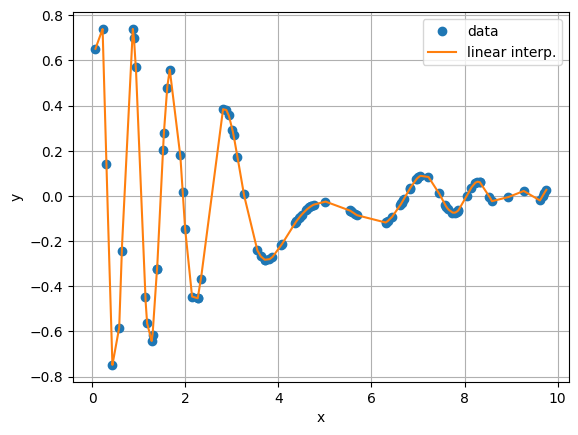

In [12]:
def interpolate_linear(x_data, y_data, x):
    i = np.searchsorted(x_data, x) - 1
    i = np.where(i < 0, 0, i)
    m = np.diff(y_data) / np.diff(x_data)
    return y_data[i] + m[i] * (x - x_data[i])


n_data = 100
rng = np.random.default_rng(42)

x_data = np.sort(rng.uniform(low=0, high=10, size=n_data))
y_data = np.sin(x_data * (10 - x_data)) * np.exp(-x_data / 3)

x = np.linspace(x_data.min(), x_data.max(), 1_000_000)
y = interpolate_linear(x_data, y_data, x)


plt.plot(x_data, y_data, "o", label="data")
plt.plot(x, y, label="linear interp.")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.legend()
plt.show()

In [13]:
from cProfile import Profile
from pstats import Stats

with Profile() as pr:
    y = interpolate_linear(x_data, y_data, x)
stats = Stats(pr)
stats.strip_dirs()
stats.sort_stats("tottime")
stats.print_stats()

         677 function calls (671 primitive calls) in 0.010 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.005    0.005    0.005    0.005 {method 'searchsorted' of 'numpy.ndarray' objects}
      2/1    0.003    0.002    0.010    0.010 2823643808.py:1(interpolate_linear)
        2    0.001    0.000    0.001    0.000 {method '__exit__' of 'sqlite3.Connection' objects}
        1    0.000    0.000    0.000    0.000 {method 'execute' of 'sqlite3.Connection' objects}
        1    0.000    0.000    0.002    0.002 history.py:100(only_when_enabled)
        4    0.000    0.000    0.000    0.000 attrsettr.py:66(_get_attr_opt)
       14    0.000    0.000    0.000    0.000 socket.py:623(send)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        2    0.000    0.000    0.000    0.000 iostream.py:348(<lambda>)
        2    0.000    0.000    0.000    0.000 zmqstream.py:546(_ru

Vergleichen wir mit einer nicht-vektorisierten Implementierung.


In [14]:
def interpolate_linear_slow1(x_data, y_data, x):
    y = []
    for x_k in x:
        i = 0
        while i < len(x_data) and x_data[i] < x_k:
            i += 1
        if i == 0:
            i = 1
        elif i == len(x_data):
            i = len(x_data) - 1
        x_lower = x_data[i - 1]
        x_upper = x_data[i]
        y_lower = y_data[i - 1]
        y_upper = y_data[i]
        y_k = (y_upper - y_lower) / (x_upper - x_lower) * (x_k - x_lower) + y_lower
        y.append(y_k)
    return np.array(y)


with Profile() as pr:
    y = interpolate_linear_slow1(x_data, y_data, x)
stats = Stats(pr)
stats.strip_dirs()
stats.sort_stats("cumtime")
stats.print_stats()

         53493788 function calls (53493783 primitive calls) in 6.517 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.000    0.000    6.342    1.268 base_events.py:1966(_run_once)
        5    0.004    0.001    6.341    1.268 selectors.py:540(select)
        1    2.951    2.951    4.214    4.214 3124833435.py:1(interpolate_linear_slow1)
        4    1.511    0.378    2.124    0.531 {method 'control' of 'select.kqueue' objects}
 52493049    1.836    0.000    1.836    0.000 {built-in method builtins.len}
        5    0.000    0.000    0.087    0.017 events.py:92(_run)
        5    0.000    0.000    0.087    0.017 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.087    0.043 zmqstream.py:573(_handle_events)
        1    0.000    0.000    0.087    0.087 asyncio.py:206(_handle_events)
        2    0.000    0.000    0.087    0.043 zmqstream.py:614(_handle_recv)
        2    0.000  

Die Funktion `len` verbraucht 3.421 von total 12.716 Sekunden, kumuliert über 52'493'051 aufrufe. Versuchen wir das zu verbessern.


In [15]:
def interpolate_linear_slow2(x_data, y_data, x):
    n = len(x_data)
    y = []
    for x_k in x:
        i = 0
        while i < n and x_data[i] < x_k:
            i += 1
        if i == 0:
            i = 1
        elif i == n:
            i = n - 1
        x_lower = x_data[i - 1]
        x_upper = x_data[i]
        y_lower = y_data[i - 1]
        y_upper = y_data[i]
        yi = (y_upper - y_lower) / (x_upper - x_lower) * (x_k - x_lower) + y_lower
        y.append(yi)
    return np.array(y)


with Profile() as pr:
    y = interpolate_linear_slow2(x_data, y_data, x)
stats = Stats(pr)
stats.strip_dirs()
stats.sort_stats("cumtime")
stats.print_stats()

         1000684 function calls (1000680 primitive calls) in 2.536 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    2.467    0.822 base_events.py:1966(_run_once)
        3    0.004    0.001    2.467    0.822 selectors.py:540(select)
        1    2.282    2.282    2.334    2.334 559756653.py:1(interpolate_linear_slow2)
        2    0.124    0.062    0.129    0.064 {method 'control' of 'select.kqueue' objects}
        3    0.000    0.000    0.068    0.023 events.py:92(_run)
        3    0.000    0.000    0.068    0.023 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.068    0.034 zmqstream.py:573(_handle_events)
        1    0.000    0.000    0.068    0.068 asyncio.py:206(_handle_events)
        2    0.000    0.000    0.068    0.034 zmqstream.py:614(_handle_recv)
        2    0.000    0.000    0.068    0.034 zmqstream.py:546(_run_callback)
        2    0.000    

Das hat sehr viel geholfen. Der grösste Anteil der total noch 4.606 s wird jetzt in der Methode `append` der Liste `y` verbracht (0.105 s kumuliert über 1'000'000 Aufrufe).

Da wir die Länge dieses Arrays kennen, können wir es vorher mit `np.empty_like` initialisieren.


In [16]:
def interpolate_linear_slow3(x_data, y_data, x):
    n = len(x_data)
    y = np.empty_like(x)
    for k, x_k in enumerate(x):
        i = 0
        while i < n and x_data[i] < x_k:
            i += 1
        if i == 0:
            i = 1
        elif i == n:
            i = n - 1
        x_lower = x_data[i - 1]
        x_upper = x_data[i]
        y_lower = y_data[i - 1]
        y_upper = y_data[i]
        y[k] = (y_upper - y_lower) / (x_upper - x_lower) * (x_k - x_lower) + y_lower
    return y


with Profile() as pr:
    y = interpolate_linear_slow3(x_data, y_data, x)
stats = Stats(pr)
stats.strip_dirs()
stats.sort_stats("cumtime")
stats.print_stats()

         684 function calls (680 primitive calls) in 2.444 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.000    0.000    2.350    0.783 base_events.py:1966(_run_once)
        3    0.000    0.000    2.350    0.783 selectors.py:540(select)
        1    2.247    2.247    2.247    2.247 3589582048.py:1(interpolate_linear_slow3)
        2    0.103    0.051    0.103    0.051 {method 'control' of 'select.kqueue' objects}
        3    0.000    0.000    0.094    0.031 events.py:92(_run)
        3    0.000    0.000    0.094    0.031 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.094    0.047 zmqstream.py:573(_handle_events)
        1    0.000    0.000    0.094    0.094 asyncio.py:206(_handle_events)
        2    0.000    0.000    0.094    0.047 zmqstream.py:614(_handle_recv)
        2    0.000    0.000    0.094    0.047 zmqstream.py:546(_run_callback)
        2    0.000    0.000  

Allerdings wird nun die restliche Zeit durch die Rechenoperationen, den for-loop und den while-loop verbraucht. Die nächste Verbesserung wäre also, `np.searchsorted` statt den while-loop zu benutzen.


In [17]:
def interpolate_linear_slow4(x_data, y_data, x):
    n = len(x_data)
    y = np.empty_like(x)
    for k, x_k in enumerate(x):
        i = np.searchsorted(x_data, x_k)
        if i == 0:
            i = 1
        elif i == n:
            i = n - 1
        x_lower = x_data[i - 1]
        x_upper = x_data[i]
        y_lower = y_data[i - 1]
        y_upper = y_data[i]
        y[k] = (y_upper - y_lower) / (x_upper - x_lower) * (x_k - x_lower) + y_lower
    return y


with Profile() as pr:
    y = interpolate_linear_slow4(x_data, y_data, x)
stats = Stats(pr)
stats.strip_dirs()
stats.sort_stats("cumtime")
stats.print_stats()

         5000754 function calls (5000749 primitive calls) in 1.332 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      2/1    0.605    0.303    1.324    1.324 2669866335.py:1(interpolate_linear_slow4)
  1000000    0.171    0.000    0.687    0.000 fromnumeric.py:1421(searchsorted)
  1000000    0.162    0.000    0.516    0.000 fromnumeric.py:48(_wrapfunc)
  1000000    0.312    0.000    0.312    0.000 {method 'searchsorted' of 'numpy.ndarray' objects}
  1000005    0.042    0.000    0.042    0.000 {built-in method builtins.getattr}
  1000000    0.038    0.000    0.038    0.000 fromnumeric.py:1417(_searchsorted_dispatcher)
        2    0.001    0.001    0.011    0.005 iostream.py:348(<lambda>)
        5    0.000    0.000    0.008    0.002 events.py:92(_run)
        5    0.000    0.000    0.008    0.002 {method 'run' of '_contextvars.Context' objects}
        2    0.000    0.000    0.008    0.004 zmqstream.py:573(_handle_even

Und dann noch den for-loop durch eine vektorisierte Implementierung ersetzen. Das ist genau das, was wir in der schnellen Version `interpolate_linear` bereits gemacht haben.


#### 4.3 Visualisierung mit [`snakeviz`](https://jiffyclub.github.io/snakeviz/)


Mit dem Package [`snakeviz`](https://jiffyclub.github.io/snakeviz/) können wir die Profiling-Daten visualisieren. Zuerst installieren

```bash
pip install snakeviz
```

und dann können wir Snakeviz direkt mit `%load_ext snakeviz` aktivierem und mit `%snakeviz -t` pro Zeile oder `%%snakeviz -t` pro Zelle im Jupyter Notebook benutzen. Wegen der Option `-t` wird die Visualisierung im Browser geöffnet. (Ohne `-t` müsste die Visualisierung eigentlich direkt im Notebook dargestellt werden, funktioniert bei mir aber nicht).

Mehr infos z.B. hier:

- https://jiffyclub.github.io/snakeviz/
- https://coderzcolumn.com/tutorials/python/snakeviz-visualize-profiling-results-in-python


In [18]:
%load_ext snakeviz

In [19]:
%snakeviz -t interpolate_linear_slow2(x_data, y_data, x)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpjqosd5mc'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpjqosd5mc


In [20]:
%%snakeviz -t

interpolate_linear_slow1(x_data, y_data, x)

 
*** Profile stats marshalled to file '/var/folders/p7/c2v89_m12k7dbrfs0m28h1640000gr/T/tmpzmk0epyc'.
Opening SnakeViz in a new tab...
snakeviz web server started on 127.0.0.1:8080; enter Ctrl-C to exit
http://127.0.0.1:8080/snakeviz/%2Fvar%2Ffolders%2Fp7%2Fc2v89_m12k7dbrfs0m28h1640000gr%2FT%2Ftmpzmk0epyc


Leider eignet sich dieses Beispiel nicht so gut für die Visualisierung. Profiling ist dann sinnvoll, wenn man komplexere Algorithmen oder Anwendungen nach Performance-Engpässen analysieren möchte. Die Visualisierung ist dann sehr hilfreich, um die Engpässe zu finden und die Performance zu verbessern.